In [1]:
##Import main libraries
import tensorflow as tf
import os


In [2]:
##So basically Tensorflow can consume all the GPU memory to limit that we are doing this 

##this line specifies nUmber of the GPUS
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
##This tells the GPU to use only the memory which is necessary to use

In [3]:
##Now we will remove the Dodgy images from the dataset
import cv2
import imghdr
image_exts = ['jpeg','jpg','bmp','png']
data_dir = ('Data')

C:\Users\Moinuddin Ghare\AppData\Local\Temp\ipykernel_26892\4163991910.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [4]:
##This checks whether the image is in the list of the image extensions or not if not then it will remove that image from the dataset
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path = os.path.join(data_dir,image_class,image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))

In [5]:
##Now we will load the dataset
import numpy as np
from matplotlib import pyplot as plt
data = tf.keras.utils.image_dataset_from_directory('Data',seed = 42)
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()


Found 2023 files belonging to 2 classes.


###0 for the CAT and 1 for the DOG


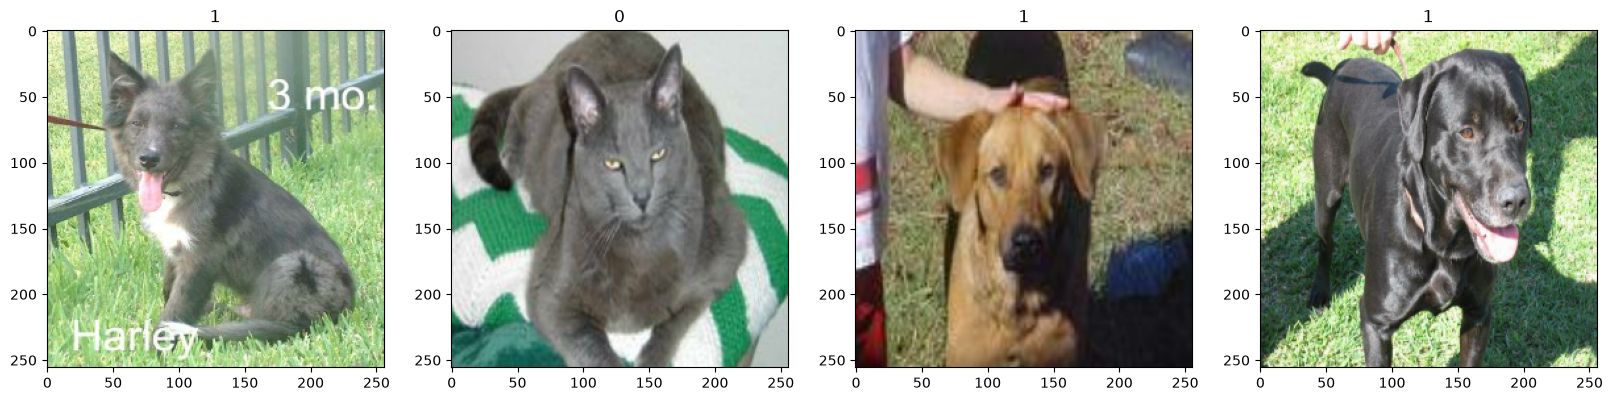

In [6]:
##Now we will plot a Batch of image to know to which class they belong to
fig , ax = plt.subplots(ncols = 4,figsize = (20,20))
for idx,img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [7]:
##Now we will preprocess the data to make it suitable for the model
##We do NOT manually scale to 0-1 here anymore. MobileNetV2 expects its own
##preprocessing (scaling pixels to -1..1), which we'll do INSIDE the model instead.
data = data.cache()


##Now we will split the data
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = len(data) - train_size - val_size


In [8]:
train_size + val_size + test_size


64

In [9]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [10]:
##Now we will build the model using TRANSFER LEARNING
##Our dataset (~2000 images) is too small to train a CNN from scratch reliably,
##so instead we reuse MobileNetV2, a CNN pretrained on ImageNet (1.4M images),
##and just train a small classifier head on top of it.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Rescaling
from tensorflow.keras.applications import MobileNetV2##This is google trained model


In [11]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
##Basically make the data more by making the same image in different angle and ways
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [12]:
##Load MobileNetV2 pretrained on ImageNet, without its original classification head
base_model = MobileNetV2(
    input_shape=(256,256,3),
    include_top=False,
    weights='imagenet'
)

##Freeze the pretrained backbone so we don't destroy its learned features
##It has learn like rich set of attributes like edges and fur texture etc. which is useful for our dataset as well as our dataset is small
##while our randomly-initialized head is still training
base_model.trainable = False

model = Sequential()
model.add(data_augmentation)

##MobileNetV2 expects pixels scaled to [-1, 1], not [0, 1] or [0, 255]
model.add(Rescaling(1./127.5, offset=-1))

model.add(base_model)
model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

##Only the Dense head (~small number of params) actually trains here.
##The MobileNetV2 backbone stays frozen with its stable, pretrained BatchNorm stats,
##which is exactly what was unstable in our from-scratch version.


C:\Users\Moinuddin Ghare\AppData\Local\Temp\ipykernel_26892\1142809401.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [13]:
model.compile('adam',loss = tf.losses.BinaryCrossentropy(),metrics = ['accuracy'])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

##Checks the val_loss if not better for like 5 epochs it stops the training and returns the best model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

hist = model.fit(train,epochs = 20,validation_data = val,callbacks = [tensorboard_callback, early_stopping])


c:\Users\Moinuddin Ghare\Desktop\python with ai\Project Internship\drowsiness_detection\train-env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9403 - loss: 0.1398 - val_accuracy: 0.9974 - val_loss: 0.0158
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9751 - loss: 0.0621 - val_accuracy: 0.9948 - val_loss: 0.0201
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9815 - loss: 0.0451 - val_accuracy: 0.9844 - val_loss: 0.0323
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9794 - loss: 0.0537 - val_accuracy: 0.9922 - val_loss: 0.0357
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9872 - loss: 0.0465 - val_accuracy: 0.9974 - val_loss: 0.0129
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9830 - loss: 0.0441 - val_accuracy: 0.9948 - val_loss: 0.0110
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9858 - loss: 0.0368 - val_accuracy: 0.9974 - val_loss: 0.0114
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9943 - loss: 0.0200 - val_accuracy: 1.0000 - val_loss:

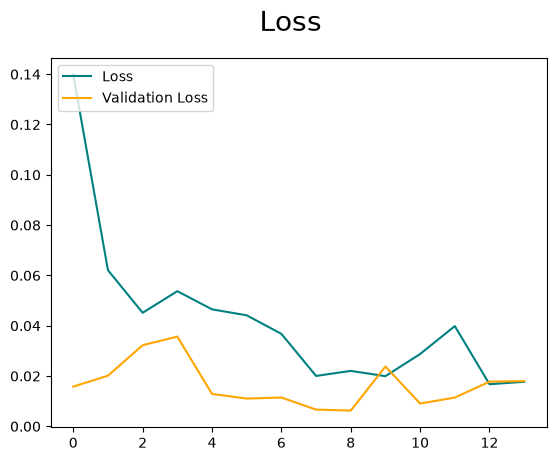

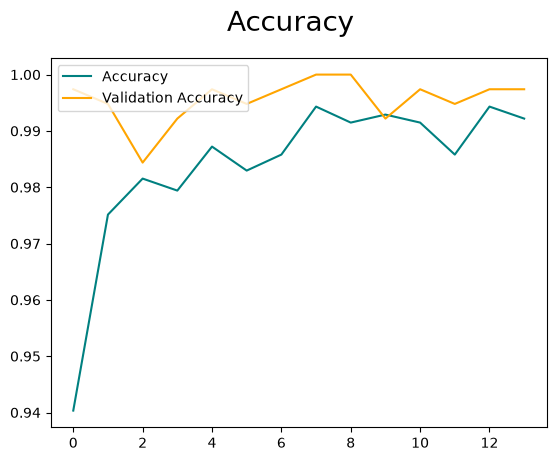

In [16]:
##Ploting the loss and accuracy
fig = plt.figure()
plt.plot(hist.history['loss'],color = 'teal',label = 'Loss')
plt.plot(hist.history['val_loss'],color = 'orange',label = 'Validation Loss')
fig.suptitle('Loss',fontsize = 20)
plt.legend(loc = 'upper left')  
plt.show()


fig = plt.figure()
plt.plot(hist.history['accuracy'],color = 'teal',label = 'Accuracy')
plt.plot(hist.history['val_accuracy'],color = 'orange',label = 'Validation Accuracy')
fig.suptitle('Accuracy',fontsize = 20)
plt.legend(loc = 'upper left')  
plt.show()


In [17]:
##Evaluating the performance
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

pre = Precision()
re = Recall()
BA = BinaryAccuracy()
for batch in test.as_numpy_iterator():
    X,y = batch
    yhat = model.predict(X)
    yhat = np.round(yhat).astype(int)
    pre.update_state(y,yhat)
    re.update_state(y,yhat) 
    BA.update_state(y,yhat)
print(f'Precision: {pre.result().numpy()}, Recall: {re.result().numpy()}, Accuracy: {BA.result().numpy()}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Precision: 0.9918032884597778, Recall: 1.0, Accuracy: 0.9956709742546082


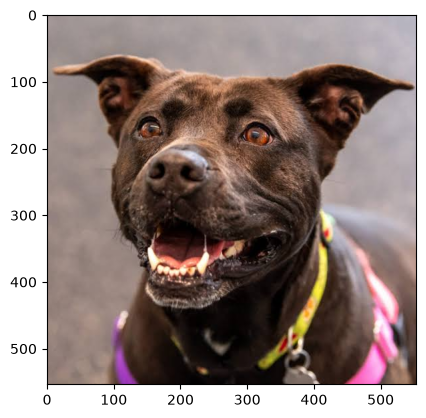

In [23]:
##Now we will test the model with unseen data
img = cv2.imread('Dog.jpg')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))##This converts the colors from bgr to rgb
plt.show()

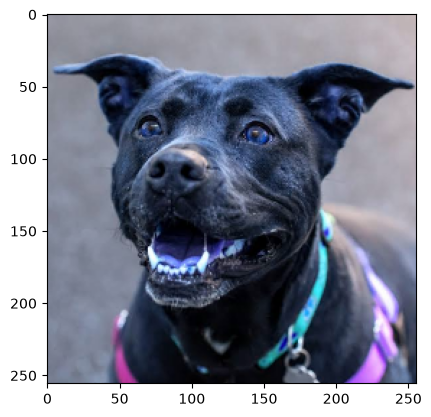

In [24]:
resize = tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))##OG form of cv2
plt.show()

In [25]:
yhat = model.predict(np.expand_dims(resize,0))
yhat


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[0.9999599]], dtype=float32)

In [26]:
if yhat > 0.5:
    print("This is a Dog")
else:
    print("This is a Cat")

This is a Dog
